In [0]:
%pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F
import datetime as datetime
from prophet import Prophet


In [0]:
events = spark.table("events_silver").toPandas()
print(events.head())
events.info()

   visitorid event  itemid  transactionid  ...  year month  day  hour
0     257597  view  355908            NaN  ...  2015     6    2     5
1     992329  view  248676            NaN  ...  2015     6    2     5
2     111016  view  318965            NaN  ...  2015     6    2     5
3     483717  view  253185            NaN  ...  2015     6    2     5
4     951259  view  367447            NaN  ...  2015     6    2     5

[5 rows x 10 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   visitorid      int64  
 1   event          object 
 2   itemid         int64  
 3   transactionid  float64
 4   timestamp      int64  
 5   event_time     object 
 6   year           int32  
 7   month          int32  
 8   day            int32  
 9   hour           int32  
dtypes: float64(1), int32(4), int64(3), object(2)
memory usage: 168.2+ MB


In [0]:
events.event_time = pd.to_datetime(events.event_time)
events.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 10 columns):
 #   Column         Dtype         
---  ------         -----         
 0   visitorid      int64         
 1   event          object        
 2   itemid         int64         
 3   transactionid  float64       
 4   timestamp      int64         
 5   event_time     datetime64[ns]
 6   year           int32         
 7   month          int32         
 8   day            int32         
 9   hour           int32         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(3), object(1)
memory usage: 168.2+ MB


In [0]:
events_group = events.groupby("event")["year"].count()
events_group.head(90)


event
addtocart        69332
transaction      22457
view           2664312
Name: year, dtype: int64

In [0]:
df = spark.sql("SELECT * FROM retail_rocket.db.ts_purchases").toPandas()

<Axes: >

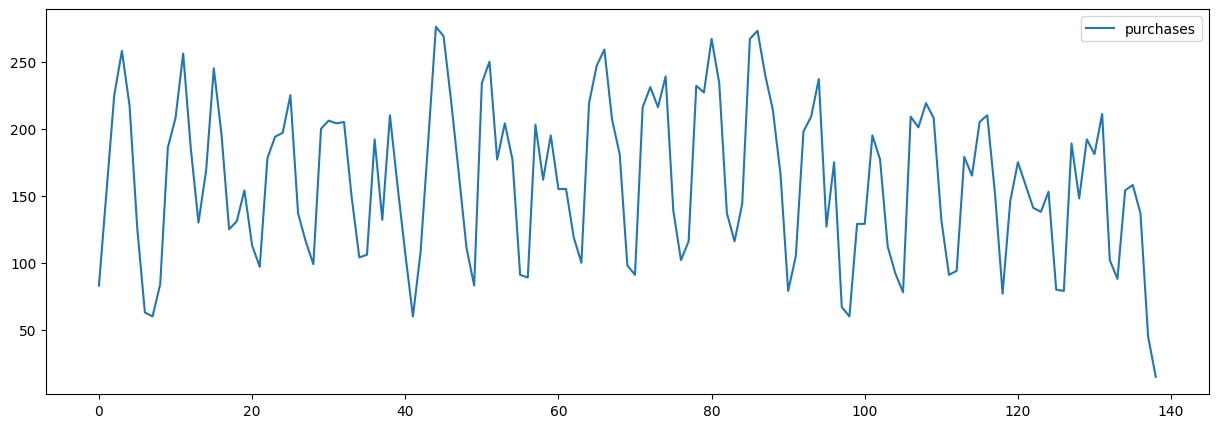

In [0]:
df.plot(figsize=(15, 5))

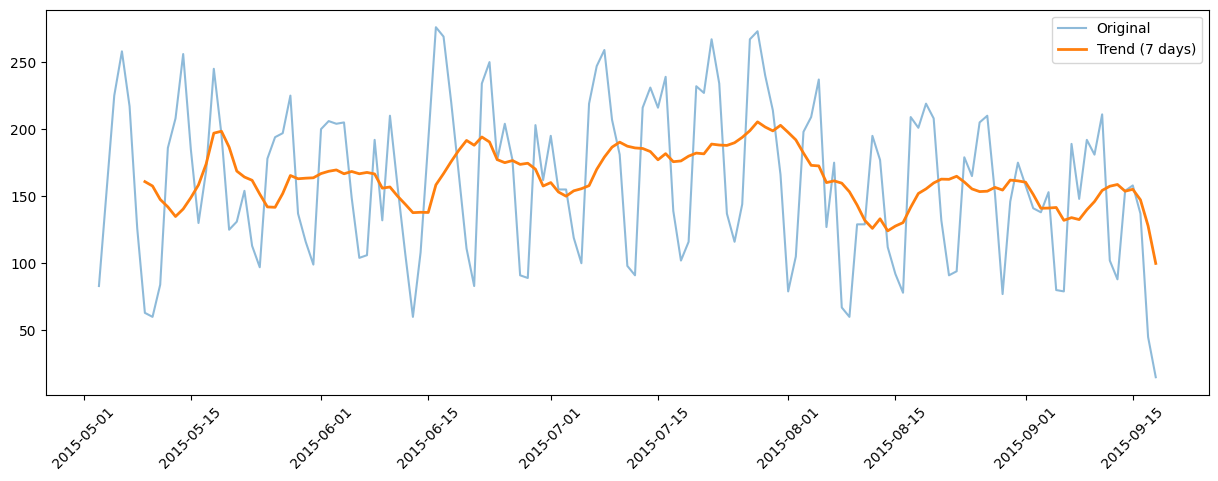

In [0]:
df["rolling_mean"] = df["purchases"].rolling(window=7).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df["date"], df["purchases"], label="Original", alpha=0.5)
plt.plot(df["date"], df["rolling_mean"], label="Trend (7 days)", linewidth=2)
plt.legend()
plt.xticks(rotation=45)
plt.show()


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Sunday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Saturday')])

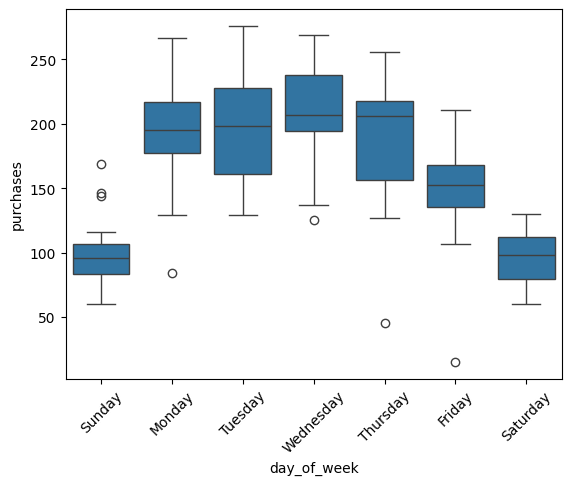

In [0]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.day_name()
sns.boxplot(x="day_of_week", y="purchases", data=df)
plt.xticks(rotation=45)

In [0]:
df_prophet = df[["date", "purchases"]].rename(columns={
    "date": "ds",
    "purchases": "y"
})


In [0]:
model = Prophet()
model.fit(df_prophet)

19:02:01 - cmdstanpy - INFO - Chain [1] start processing
19:02:01 - cmdstanpy - INFO - Chain [1] done processing


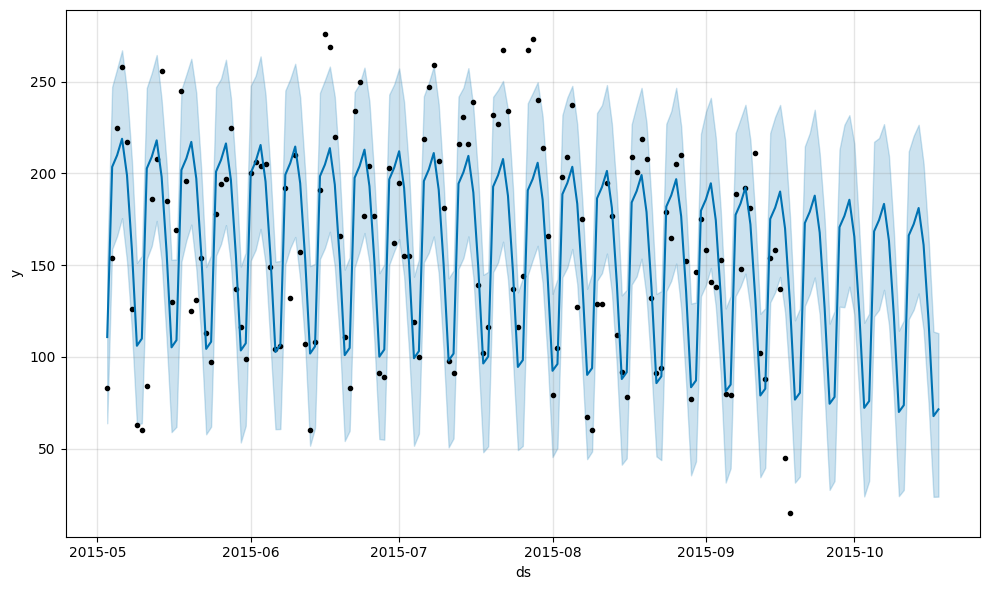

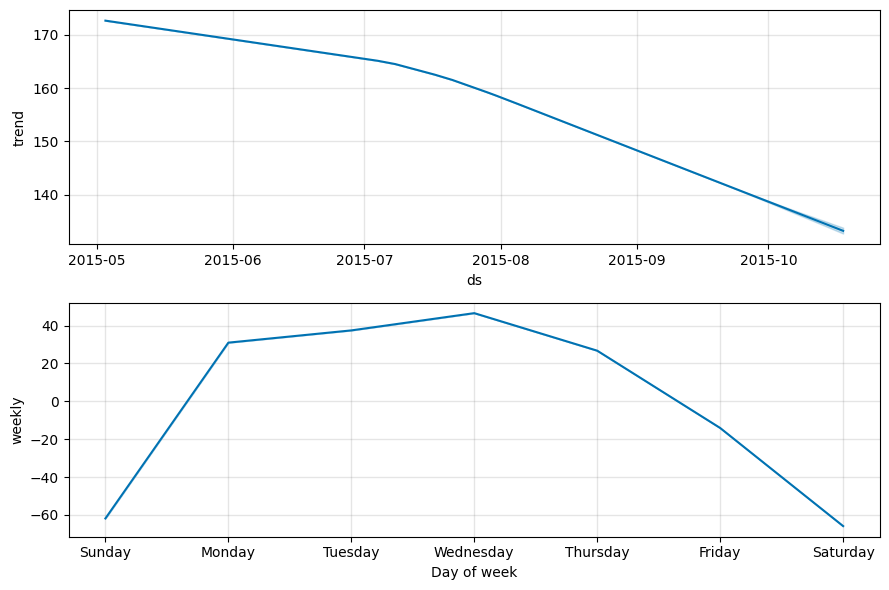

In [0]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.show()

fig2 = model.plot_components(forecast)
plt.show()


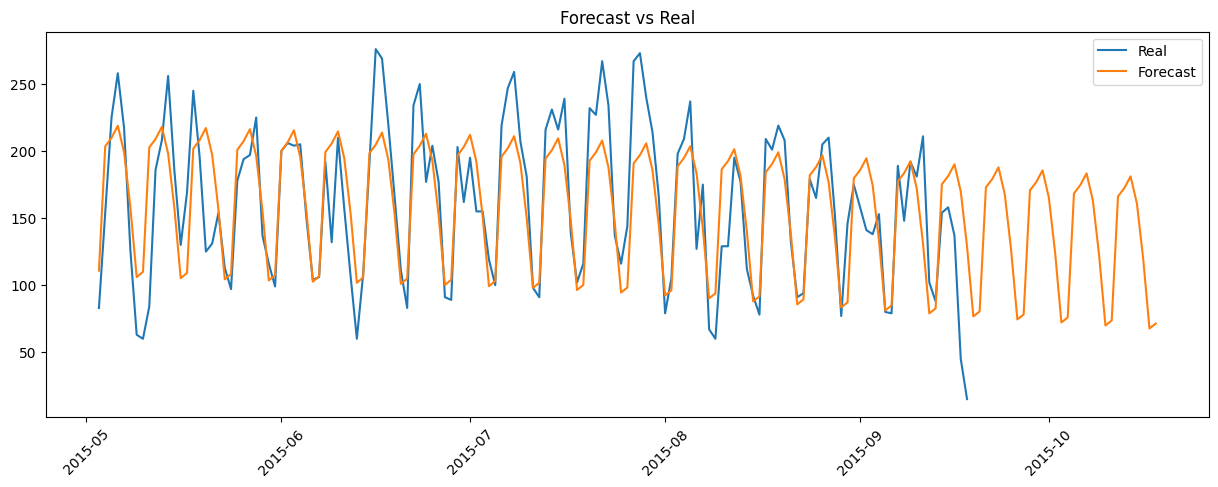

In [0]:
plt.figure(figsize=(15,5))

plt.plot(df_prophet["ds"], df_prophet["y"], label="Real")
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast")

plt.legend()
plt.title("Forecast vs Real")
plt.xticks(rotation=45)

plt.show()